# Contents
This script parses fit results of `parse_data_and_fit.ipynb`, and compares the two flow rates (10slm and 20slm) at the same location (upstream or downstream). It creates some plots in `output/media` which are used in the paper.

# Instructions
1. Change `upstream` (True or False).
2. Run all cells.

In [ ]:
# Variables
upstream = False # True to look at z=-40mm (upstream), False z=20mm (downstream)

# Constants
pressure = 120
power = 1000 # [W]

# Compare flowrates (Fig. 8)

In [6]:
import wedme
import numpy as np
import matplotlib.pyplot as plt
import toddler
from pathlib import Path
import os

dir_root = Path(os.getcwd())

dir_out = dir_root / "output" # Storage of the output of this work: flow profiles and fitted parameters
dir_media = dir_out / "media" # Storage of generated media (e.g. plots)
dir_output_data = dir_out / "data" # Storage of generated data (e.g. flow profiles)

In [7]:
if upstream:
    z_load = -40
else:
    z_load = 20

# stylename = 'slide'
stylename = 'paper'

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


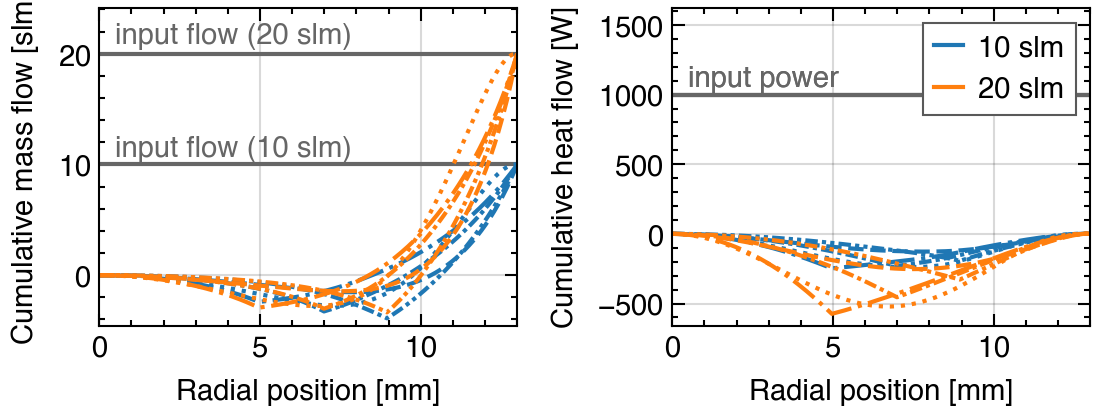

In [8]:
from matplotlib import style
from matplotlib.lines import Line2D

wedme.apply.paper()

linestyles = [
    "-",
    (0, (9, 3)),
    (0, (6.5, 2)),
    "--",
    "-.",
    (0, (3, 1, 1, 1)),
    (0, (3, 1, 1, 1, 1, 1)),
    ":",
]
r_arrow = 9 # was 7
colors = plt.cm.tab10.colors

# fig, axes = wedme.subplots.dev(3, len(plots), figsize=(len(plots) * wedme.PAPER_SCW/2, 3 * wedme.PAPER_SCW/2 / 1.618), sharex='col', sharey='row', squeeze=False)

# fig, axes = wedme.subplots.slide(1, 2, figsize=(wedme.SLIDE_FW, wedme.SLIDE_TTH), squeeze=False)
if stylename == 'paper': fig, (ax1, ax2) = wedme.subplots.paper(1, 2, width_ratios=[1,1], figsize=(wedme.PAPER_SCW*0.8, wedme.PAPER_DH*0.7))
elif stylename == 'slide': fig, (ax1, ax2) = wedme.subplots.slide_fw_tth(1, 2, width_ratios=[1,1])
# fig.suptitle(fr"{meas_title} @ $z={z0:.0f}\mathrm{{ mm}}$")

for k, flowrate in enumerate([10, 20]):
    color = colors[k]

    reverse_vortex = False
    # Load results from Pkl file
    f_load = flowrate
    meas_title = fr"{'RV' if reverse_vortex else 'FV'} {f_load}slm $\mathrm{{CO_2}}$, {pressure}mbar, 1000W"
    meas_filename = fr"{'rv' if reverse_vortex else 'fv'}_{f_load}slm_CO2_{pressure}mbar_1000W"

    obj = toddler.files.saving.load_from_pkl(dir_output_data / f"massflux_profiles_{meas_filename}_z{z_load:.0f}.pkl")
    r_sim = obj['r']
    z0 = obj['z0']
    plots = obj['profiles']
    profile_names = obj['profile_names']
    massflux_abs = obj['massflux']
    massflow_diff = obj['massflow_diff']
    massflow_cum = obj['massflow_cum']
    massflow_cum_slm = obj['massflow_cum_slm']
    heatflux = obj['heatflux']
    heatflux_diff = obj['heatflux_diff']
    heatflux_cum = obj['heatflux_cum']
    velocity = obj['velocity']
    successes = obj['successes']
    ressum = obj['ressum']
    # specific_enthalpy_sim = obj['specific_enthalpy']
    power_fraction = obj['power_fraction']
    SEI = obj['SEI']
    pressure = obj['pressure']
    flowrate = obj['flowrate']
    power = obj['power']
    
    linestyles_plot = []

    idx_skip = []
    idx_noskip = 0
    for i, (name, fitparameter, fitfunction, refit) in enumerate(plots):
        if 'ecirculation' in name or 'Linear mass flux' in name or '3mm' in name: 
            idx_skip.append(i)
            linestyles_plot.append(None)
        else:
            linestyles_plot.append(linestyles[idx_noskip])
            idx_noskip += 1

    ax2.hlines(power, 0, 13, '#666', linestyle='-')    
    ax2.text(0.5, power*1.02, "input power", color='#666', verticalalignment='bottom')
    ax1.hlines(flowrate, 0, 13, '#666', linestyle='-')    
    ax1.text(0.5, flowrate*1.02, f"input flow ({flowrate:.0f} slm)", color='#666', verticalalignment='bottom')
    for i, (name, fitparameter, fitfunction, refit) in enumerate(plots):
        success = successes[i]
        if ~success: continue
        if i in idx_skip: continue
    
        # print(fit_report(out))

        ax1.plot(r_sim, massflow_cum_slm[i, :], linestyle=linestyles_plot[i], color=color)
        ax2.plot(r_sim, heatflux_cum[i, :], color=color, linestyle=linestyles_plot[i], label=name)


        # fig.suptitle(f"{name}\n{'possible' if success else f'{np.sum(np.sqrt(res[0:2]))*100:.0f}% violation'}", color=color, y=0.9)
        # ax1.set_title(f"{name}\n{'Possible (can satisfy conservation laws)' if success else 'Impossible (always violates conservation laws)'}", color='green' if success else 'red')
        # ax1.set_title(fr"$z={z0}\mathrm{{ mm}}$ ({meas_title})")
        for ax in [ax1, ax2]:
            ax.set_xlim(0, 13)

            # If all data in this axis is >0, set ylim to 0
            maxy = np.nanmax(ax.lines[0].get_ydata())
            miny = np.nanmin(ax.lines[0].get_ydata())
            diffy = max(maxy - miny, abs(maxy), abs(miny))

            # ax.set_ylim(min(miny-diffy * 0.1, 0), maxy + diffy * 0.1)
            # if np.all(ax.lines[0].get_ydata() > 0):
            #     ax.set_ylim(0)
            ax.set_xlabel("Radial position [mm]")
        # ax1.set_ylim(-1, 2.5)

        # for ax in [ax1, ax2]:
        #     ax.set_xticklabels([])


        # if i == 0:
        ax1.set_ylabel(r"Cumulative mass flow [$\mathrm{slm}$]")
        ax2.set_ylabel(r"Cumulative heat flow [$\mathrm{W}$]")


    id_rhalf = np.argmin(np.abs(r_sim - r_arrow))
    

    ax1.set_ylim(top=max(flowrate, np.max(massflow_cum_slm))*1.2)
    ax2.set_ylim(top=max(power, np.max(heatflux_cum))*1.2, bottom=min(0, np.min(heatflux_cum)))

        # ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), handlelength=2)
    custom_lines = [Line2D([0], [0], color=colors[0]),
                    Line2D([0], [0], color=colors[1])]
    first_legend = ax2.legend(custom_lines, ['10 slm', '20 slm'])#, loc='upper left', bbox_to_anchor=(1, 1))
    # ax2.add_artist(first_legend)

    # if j == 0:
    #     asd = ax2.legend(loc='lower left', bbox_to_anchor=(1, 0), handlelength=2)
    #     for i in range(len(asd.legendHandles)):
    #         asd.legendHandles[i].set_color('k')

        # fig.savefig(dir_out / "media" / f"summary_z{z0:.0f}_{meas_filename}_slides_alt2.pdf", bbox_inches='tight', dpi=1000)
fig.savefig(dir_media / f"{meas_filename}_z{z0:.0f}_vs_10slm_cumulativeflows_{stylename}.pdf", bbox_inches='tight', pad_inches=0.05, dpi=1000)
plt.show()